Step 31 — Create the new notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/customer_segmentation.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4338, 19)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerLifespanDays,ActiveMonths,OrdersPerActiveMonth,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score,Segment,KMeansCluster,BehavioralSegment
0,12346,326,1,77183.60,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0,1,1.0,1,1,5,7,Hibernating,0,At-Risk Valuable Customers
1,12347,2,7,4310.00,2458,103,615.714286,2010-12-07 14:57:00,2011-12-07 15:52:00,365,7,1.0,5,5,5,15,Champions,3,Engaged Loyal Customers
2,12348,75,4,1797.24,2341,22,449.310000,2010-12-16 19:09:00,2011-09-25 13:13:00,282,4,1.0,2,4,4,10,Can't Lose Them,3,Engaged Loyal Customers
3,12349,19,1,1757.55,631,73,1757.550000,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1,1.0,4,1,4,9,Lost Customers,0,At-Risk Valuable Customers
4,12350,310,1,334.40,197,17,334.400000,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1,1.0,1,1,2,4,Lost Customers,0,At-Risk Valuable Customers


Step 32 — Build the CLTV foundation

In [2]:
# Convert purchase dates to datetime
df["FirstPurchase"] = pd.to_datetime(df["FirstPurchase"])
df["LastPurchase"] = pd.to_datetime(df["LastPurchase"])

# Observation period in days
observation_end = df["LastPurchase"].max()

# Customer lifetime in months
df["CustomerLifespanMonths"] = (
    (df["LastPurchase"] - df["FirstPurchase"]).dt.days / 30.44
)

# Avoid zero-month lifetimes for one-time customers
df["CustomerLifespanMonths"] = (
    df["CustomerLifespanMonths"].clip(lower=1/30.44)
)

# Historical monthly purchase frequency
df["PurchasesPerMonth"] = (
    df["Frequency"] /
    df["CustomerLifespanMonths"]
)

# Historical average monthly revenue
df["RevenuePerMonth"] = (
    df["Monetary"] /
    df["CustomerLifespanMonths"]
)

print(df[
    [
        "CustomerID",
        "Frequency",
        "Monetary",
        "CustomerLifespanMonths",
        "PurchasesPerMonth",
        "RevenuePerMonth"
    ]
].head(10))

   CustomerID  Frequency  Monetary  CustomerLifespanMonths  PurchasesPerMonth  \
0       12346          1  77183.60                0.032852          30.440000   
1       12347          7   4310.00               11.990802           0.583781   
2       12348          4   1797.24                9.264126           0.431773   
3       12349          1   1757.55                0.032852          30.440000   
4       12350          1    334.40                0.032852          30.440000   
5       12352          8   2506.04                8.541393           0.936615   
6       12353          1     89.00                0.032852          30.440000   
7       12354          1   1079.40                0.032852          30.440000   
8       12355          1    459.40                0.032852          30.440000   
9       12356          3   2811.43                9.921156           0.302384   

   RevenuePerMonth  
0     2.349469e+06  
1     3.594422e+02  
2     1.939999e+02  
3     5.349982e+04  
4  

Step 33 — Build robust customer value metrics

In [3]:
# Identify repeat customers
repeat_customers = df["Frequency"] > 1

# Median purchase frequency per active month among repeat customers
median_monthly_frequency = (
    df.loc[repeat_customers, "Frequency"] /
    df.loc[repeat_customers, "ActiveMonths"]
).median()

# Median customer lifespan among repeat customers
median_lifespan_months = (
    df.loc[repeat_customers, "CustomerLifespanMonths"]
).median()

print(
    "Median monthly purchase frequency (repeat customers):",
    round(median_monthly_frequency, 3)
)

print(
    "Median customer lifespan (months, repeat customers):",
    round(median_lifespan_months, 2)
)

Median monthly purchase frequency (repeat customers): 1.0
Median customer lifespan (months, repeat customers): 6.8


Step 34 — Calculate scenario-based CLTV

In [4]:
# Use median repeat-customer monthly purchase frequency
expected_monthly_frequency = median_monthly_frequency

# Scenario horizons
lifetime_scenarios = [6, 12, 24]

for months in lifetime_scenarios:
    df[f"CLTV_{months}M"] = (
        df["AverageOrderValue"]
        * expected_monthly_frequency
        * months
    )

# Base CLTV: 12-month planning horizon
df["CLTV"] = df["CLTV_12M"]

print(
    df[
        [
            "CustomerID",
            "AverageOrderValue",
            "Frequency",
            "Monetary",
            "CLTV_6M",
            "CLTV_12M",
            "CLTV_24M"
        ]
    ].head(10)
)

   CustomerID  AverageOrderValue  Frequency  Monetary        CLTV_6M  \
0       12346       77183.600000          1  77183.60  463101.600000   
1       12347         615.714286          7   4310.00    3694.285714   
2       12348         449.310000          4   1797.24    2695.860000   
3       12349        1757.550000          1   1757.55   10545.300000   
4       12350         334.400000          1    334.40    2006.400000   
5       12352         313.255000          8   2506.04    1879.530000   
6       12353          89.000000          1     89.00     534.000000   
7       12354        1079.400000          1   1079.40    6476.400000   
8       12355         459.400000          1    459.40    2756.400000   
9       12356         937.143333          3   2811.43    5622.860000   

        CLTV_12M      CLTV_24M  
0  926203.200000  1.852406e+06  
1    7388.571429  1.477714e+04  
2    5391.720000  1.078344e+04  
3   21090.600000  4.218120e+04  
4    4012.800000  8.025600e+03  
5    3759

In [5]:
# Customer-specific observed monthly purchase frequency
df["ObservedMonthlyFrequency"] = (
    df["Frequency"] / df["ActiveMonths"]
)

# Use observed frequency for repeat customers
# Use the repeat-customer median as a benchmark for one-time customers
df["ExpectedMonthlyFrequency"] = np.where(
    df["Frequency"] > 1,
    df["ObservedMonthlyFrequency"],
    median_monthly_frequency
)

# Scenario-based CLTV
for months in [6, 12, 24]:
    df[f"CLTV_{months}M"] = (
        df["AverageOrderValue"]
        * df["ExpectedMonthlyFrequency"]
        * months
    )

# Base CLTV for the project
df["CLTV"] = df["CLTV_12M"]

print(
    df[
        [
            "CustomerID",
            "Frequency",
            "ActiveMonths",
            "AverageOrderValue",
            "ObservedMonthlyFrequency",
            "ExpectedMonthlyFrequency",
            "CLTV_6M",
            "CLTV_12M",
            "CLTV_24M"
        ]
    ].head(10)
)

   CustomerID  Frequency  ActiveMonths  AverageOrderValue  \
0       12346          1             1       77183.600000   
1       12347          7             7         615.714286   
2       12348          4             4         449.310000   
3       12349          1             1        1757.550000   
4       12350          1             1         334.400000   
5       12352          8             4         313.255000   
6       12353          1             1          89.000000   
7       12354          1             1        1079.400000   
8       12355          1             1         459.400000   
9       12356          3             3         937.143333   

   ObservedMonthlyFrequency  ExpectedMonthlyFrequency        CLTV_6M  \
0                       1.0                       1.0  463101.600000   
1                       1.0                       1.0    3694.285714   
2                       1.0                       1.0    2695.860000   
3                       1.0             

In [6]:
# CLTV descriptive statistics
cltv_stats = df["CLTV"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print(cltv_stats)

count    4.338000e+03
mean     6.399450e+03
std      2.456687e+04
min      4.500000e+01
25%      2.344673e+03
50%      3.896571e+03
75%      6.185010e+03
90%      1.014199e+04
95%      1.445362e+04
99%      3.796064e+04
max      1.010835e+06
Name: CLTV, dtype: float64


In [7]:
# Compare mean and median CLTV
print("Mean CLTV:   £{:,.2f}".format(df["CLTV"].mean()))
print("Median CLTV: £{:,.2f}".format(df["CLTV"].median()))
print("Maximum CLTV: £{:,.2f}".format(df["CLTV"].max()))

Mean CLTV:   £6,399.45
Median CLTV: £3,896.57
Maximum CLTV: £1,010,835.00


In [8]:
cltv_by_segment = (
    df
    .groupby("BehavioralSegment")
    .agg(
        Customers=("CustomerID", "count"),
        MeanCLTV=("CLTV", "mean"),
        MedianCLTV=("CLTV", "median"),
        TotalCLTV=("CLTV", "sum"),
        MeanAOV=("AverageOrderValue", "mean"),
        MedianAOV=("AverageOrderValue", "median")
    )
    .sort_values("MedianCLTV", ascending=False)
    .reset_index()
)

cltv_by_segment

,BehavioralSegment,Customers,MeanCLTV,MedianCLTV,TotalCLTV,MeanAOV,MedianAOV
0,High-Value Champions,465,15118.892421,7914.860,7.030285e+06,567.975526,381.455455
1,At-Risk Valuable Customers,1340,7587.877016,4648.500,1.016776e+07,576.572145,370.905000
2,Engaged Loyal Customers,1418,5976.504799,4304.484,8.474684e+06,431.285671,311.066000
3,Low-Value Inactive Customers,1115,1872.726646,1762.200,2.088090e+06,146.608810,140.823333


In [9]:
# Add each segment's share of total projected CLTV
cltv_by_segment["CLTVShare"] = (
    cltv_by_segment["TotalCLTV"]
    / cltv_by_segment["TotalCLTV"].sum()
    * 100
)

cltv_by_segment

,BehavioralSegment,Customers,MeanCLTV,MedianCLTV,TotalCLTV,MeanAOV,MedianAOV,CLTVShare
0,High-Value Champions,465,15118.892421,7914.860,7.030285e+06,567.975526,381.455455,25.324491
1,At-Risk Valuable Customers,1340,7587.877016,4648.500,1.016776e+07,576.572145,370.905000,36.626286
2,Engaged Loyal Customers,1418,5976.504799,4304.484,8.474684e+06,431.285671,311.066000,30.527505
3,Low-Value Inactive Customers,1115,1872.726646,1762.200,2.088090e+06,146.608810,140.823333,7.521718


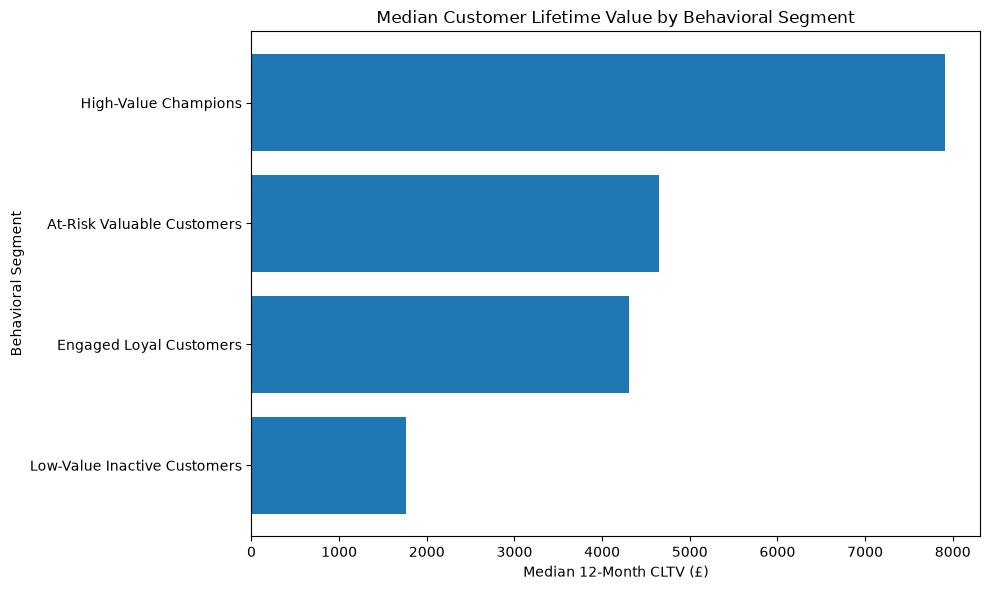

In [10]:
plt.figure(figsize=(10, 6))

plot_data = cltv_by_segment.sort_values(
    "MedianCLTV",
    ascending=True
)

plt.barh(
    plot_data["BehavioralSegment"],
    plot_data["MedianCLTV"]
)

plt.xlabel("Median 12-Month CLTV (£)")
plt.ylabel("Behavioral Segment")
plt.title("Median Customer Lifetime Value by Behavioral Segment")

plt.tight_layout()
plt.show()

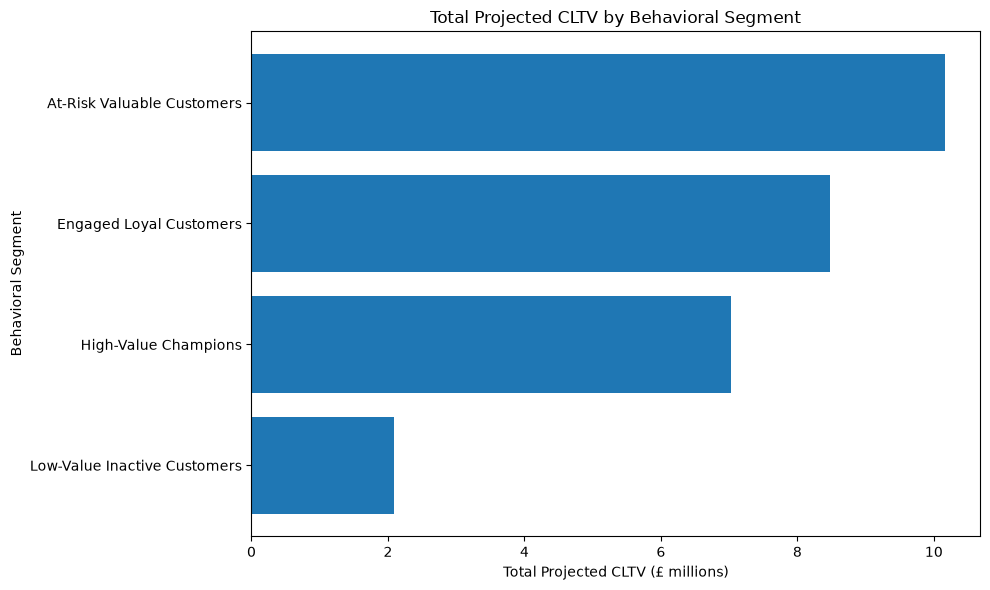

In [11]:
plt.figure(figsize=(10, 6))

plot_data = cltv_by_segment.sort_values(
    "TotalCLTV",
    ascending=True
)

plt.barh(
    plot_data["BehavioralSegment"],
    plot_data["TotalCLTV"] / 1_000_000
)

plt.xlabel("Total Projected CLTV (£ millions)")
plt.ylabel("Behavioral Segment")
plt.title("Total Projected CLTV by Behavioral Segment")

plt.tight_layout()
plt.show()

In [12]:
# Save final CLTV dataset

output_path = "../data/processed/customer_cltv.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"CLTV dataset saved successfully: {output_path}")
print("Shape:", df.shape)

CLTV dataset saved successfully: ../data/processed/customer_cltv.csv
Shape: (4338, 28)
